# Deep Q-Learning with Experience Replay and a Soft-Updated Target Network
### Training an agent to swing up an Acrobot (Gymnasium `Acrobot-v1`)

This is my practice notebook for **Deep Q-Networks (DQN)**. The goal is to understand the three ideas that make Q-learning work with neural networks:

1. A **Q-Network** that approximates the action-value function $Q(s,a)$ for a continuous state space.
2. A separate **target network** (updated with a *soft update*) that keeps the learning targets stable.
3. **Experience replay**, a memory buffer from which we sample random mini-batches to break the correlation between consecutive experiences.

The problem here is the **Acrobot**: a two-link pendulum that is hanging down. Only the joint between the two links can be actuated. The agent must learn to swing the tip of the lower link above a target line using as few steps as possible.

The notebook is fully **self-contained**. There is no helper `utils.py`, no image folder, and no autograder. Every helper function (epsilon-greedy policy, replay sampling, soft update, plotting) is written in the notebook itself, and each of the two core exercises has a small test so you can verify your own understanding.

**Outline**
- [1 - Import Packages](#1)
- [2 - Hyperparameters](#2)
- [3 - The Acrobot Environment](#3)
- [4 - Load the Environment](#4)
- [5 - Interacting with the Environment](#5)
- [6 - Deep Q-Learning](#6)
  - [6.1 Target Network (Exercise 1)](#6.1)
  - [6.2 Experience Replay](#6.2)
- [7 - Loss Function (Exercise 2)](#7)
- [8 - Update the Network Weights](#8)
- [9 - Train the Agent](#9)
- [10 - Evaluate the Trained Agent](#10)
- [11 - See the Trained Agent in Action](#11)
- [12 - Summary and Experiments to Try](#12)
- [13 - References](#13)

<a name="1"></a>
## 1 - Import Packages

We use the following packages:
- `numpy` for numerical computing.
- `deque` as the data structure of the memory buffer, and `namedtuple` to store experience tuples.
- `gymnasium` (the maintained successor of OpenAI `gym`) for the Acrobot environment. We use `pygame` only to render frames.
- `tensorflow.keras` to build the Q-networks and write a custom training loop.
- `matplotlib` for plots and `imageio` to save a GIF of the final agent.

If you run this notebook on a fresh machine, run the install cell first. TensorFlow is already available on Google Colab. Locally, also run `pip install tensorflow`.

In [1]:
# Install the lightweight dependencies (safe to re-run). Locally you also need: pip install tensorflow
%pip install -q "gymnasium[classic-control]" pygame imageio matplotlib

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # keep TensorFlow logs quiet

import random
import time
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
import tensorflow as tf
from IPython.display import Image as IPyImage, display

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("Gymnasium :", gym.__version__)

TensorFlow: 2.21.0
Gymnasium : 1.3.0


In [3]:
# Reproducibility: fix every random number generator we use
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

<a name="2"></a>
## 2 - Hyperparameters

Run the cell below to set the hyperparameters. A short note on what each one controls:

| Name | Meaning |
|---|---|
| `MEMORY_SIZE` | Capacity $N$ of the replay buffer. Old experiences are dropped when it is full. |
| `GAMMA` | Discount factor $\gamma$. How much the agent cares about future rewards. |
| `ALPHA` | Learning rate of the Adam optimizer. |
| `TAU` | Soft-update rate $\tau$ for the target network (small means the target changes slowly). |
| `BATCH_SIZE` | Number of experiences in every mini-batch. |
| `NUM_STEPS_FOR_UPDATE` | The agent performs one learning update every $C$ time steps. |
| `EPSILON_DECAY`, `EPSILON_MIN` | How fast exploration is reduced and the floor we never go below. |
| `SOLVED_SCORE` | Average reward over the last 100 episodes at which we call the task solved. |

In [4]:
MEMORY_SIZE = 50_000        # size of the replay buffer
GAMMA = 0.99                # discount factor
ALPHA = 1e-3                # learning rate
TAU = 1e-2                  # soft update parameter for the target network
BATCH_SIZE = 64             # mini-batch size
NUM_STEPS_FOR_UPDATE = 4    # learn every C time steps
EPSILON_DECAY = 0.97        # multiplicative decay of epsilon after every episode
EPSILON_MIN = 0.01          # minimum epsilon
SOLVED_SCORE = -100.0       # Acrobot-v1 is considered solved at an average of -100

<a name="3"></a>
## 3 - The Acrobot Environment

The Acrobot system has two links joined in a chain, with one end of the chain fixed. The joint between the two links is **actuated**. Both links start hanging downward. The goal is to apply torques on the actuated joint to swing the free end of the chain above a target height (the horizontal line one link-length above the fixed pivot) in as few steps as possible.

This is an interesting problem for reinforcement learning because there is no immediate "good" signal. The agent receives the same small penalty on every step and has to discover on its own that building up energy by swinging back and forth is the way to finish quickly.

<a name="3.1"></a>
### 3.1 Action Space

The agent has three discrete actions. The action is the torque applied to the actuated joint:

```python
Apply -1 torque = 0
Apply  0 torque = 1
Apply +1 torque = 2
```

<a name="3.2"></a>
### 3.2 Observation Space

The state is a vector with 6 continuous values:

| Index | Observation |
|---|---|
| 0 | $\cos(\theta_1)$ |
| 1 | $\sin(\theta_1)$ |
| 2 | $\cos(\theta_2)$ |
| 3 | $\sin(\theta_2)$ |
| 4 | Angular velocity of $\theta_1$ |
| 5 | Angular velocity of $\theta_2$ |

Here $\theta_1$ is the angle of the first joint relative to pointing straight down, and $\theta_2$ is the angle of the second link relative to the first link.

<a name="3.3"></a>
### 3.3 Rewards

The reward is **-1 on every step** until the goal is reached. This means the total reward of an episode is simply the negative of the number of steps it took. A better agent gets a total closer to 0. The maximum episode length is 500 steps, so the worst possible score is -500.

<a name="3.4"></a>
### 3.4 Episode End

Gymnasium distinguishes two different ways for an episode to end:

* **`terminated`**: the free end of the chain reached the target height. This is a real terminal state of the problem.
* **`truncated`**: the time limit of 500 steps was reached. The problem itself did not end, we just stopped the episode.

This distinction is important for Q-learning, and we will use it correctly in the loss function: only a real termination should cut off the bootstrapped future value.

<a name="4"></a>
## 4 - Load the Environment

We load `Acrobot-v1` with `gym.make()`. The environment object exposes the shape of the state vector and the number of valid actions, which we need to build the neural network.

In [5]:
env = gym.make("Acrobot-v1")

state_size = env.observation_space.shape
num_actions = int(env.action_space.n)

print("State shape       :", state_size)
print("Number of actions :", num_actions)
print("Max episode steps :", env.spec.max_episode_steps)

State shape       : (6,)
Number of actions : 3
Max episode steps : 500


<a name="5"></a>
## 5 - Interacting with the Environment

Gymnasium follows the standard **agent-environment loop**. At every discrete time step $t$ the agent observes a state $S_t$, picks an action $A_t$ using its policy $\pi$, then receives a reward $R_{t+1}$ and the next state $S_{t+1}$.

In Gymnasium the API is:

* `state, info = env.reset(seed=...)` starts a new episode.
* `next_state, reward, terminated, truncated, info = env.step(action)` runs one time step.

(Older `gym` versions return 4 values from `step` and only `state` from `reset`. Gymnasium returns 5 and 2.)

<a name="5.1"></a>
### 5.1 Exploring the Environment's Dynamics

Let us push the joint with the same torque for a few steps and watch how the state changes.

In [6]:
state, _ = env.reset(seed=SEED)
print("Initial state:", np.round(state, 3))
print()

names = ["cos(t1)", "sin(t1)", "cos(t2)", "sin(t2)", "w1", "w2"]
print(f"{'step':>4} | {'action':>6} | {'reward':>6} | " + " | ".join(f"{n:>7}" for n in names))
print("-" * 82)

action = 2   # try changing this to 0 or 1
for step in range(1, 9):
    next_state, reward, terminated, truncated, _ = env.step(action)
    print(f"{step:>4} | {action:>6} | {reward:>6.1f} | " + " | ".join(f"{v:>7.3f}" for v in next_state))
    state = next_state

Initial state: [ 0.998  0.055  1.    -0.012  0.072  0.039]

step | action | reward | cos(t1) | sin(t1) | cos(t2) | sin(t2) |      w1 |      w2
----------------------------------------------------------------------------------
   1 |      2 |   -1.0 |   0.999 |   0.048 |   0.999 |   0.036 |  -0.132 |   0.437
   2 |      2 |   -1.0 |   1.000 |   0.005 |   0.988 |   0.154 |  -0.287 |   0.719
   3 |      2 |   -1.0 |   0.998 |  -0.060 |   0.952 |   0.305 |  -0.344 |   0.797
   4 |      2 |   -1.0 |   0.992 |  -0.124 |   0.897 |   0.443 |  -0.290 |   0.653
   5 |      2 |   -1.0 |   0.986 |  -0.169 |   0.847 |   0.531 |  -0.150 |   0.342
   6 |      2 |   -1.0 |   0.984 |  -0.181 |   0.831 |   0.556 |   0.033 |  -0.048
   7 |      2 |   -1.0 |   0.988 |  -0.157 |   0.857 |   0.515 |   0.206 |  -0.426
   8 |      2 |   -1.0 |   0.995 |  -0.103 |   0.910 |   0.414 |   0.322 |  -0.699


<a name="5.2"></a>
### 5.2 A Random-Agent Baseline

Before training anything, we measure how well an agent that picks **random actions** does. This gives us a reference point to see how much the learning actually helps.

In [7]:
def run_episode(environment, policy, seed=None):
    # Play one full episode and return the total reward (and the number of steps)
    state, _ = environment.reset(seed=seed)
    total, steps, done = 0.0, 0, False
    while not done:
        action = policy(state)
        state, reward, terminated, truncated, _ = environment.step(action)
        total += reward
        steps += 1
        done = terminated or truncated
    return total, steps

random_policy = lambda s: env.action_space.sample()

random_scores = [run_episode(env, random_policy, seed=1000 + i)[0] for i in range(20)]
print(f"Random agent over 20 episodes: mean = {np.mean(random_scores):.1f}, "
      f"std = {np.std(random_scores):.1f}")

Random agent over 20 episodes: mean = -500.0, std = 0.0


<a name="6"></a>
## 6 - Deep Q-Learning

When both states and actions are discrete and few, we can store $Q(s,a)$ in a table and improve it with the **Bellman equation**:

$$
Q_{i+1}(s,a) = R + \gamma \max_{a'}Q_i(s',a')
$$

In Acrobot the state is a vector of **continuous** numbers, so there are infinitely many states and a table is impossible. Instead we use a neural network, the **Q-Network**, to approximate the action-value function, $Q(s,a;w)\approx Q^*(s,a)$. It takes a state as input and outputs one Q-value per action. We train it by adjusting the weights $w$ to minimize the mean-squared error in the Bellman equation.

Training a neural network this way is known to be unstable. Two techniques fix most of the problem: a **target network** and **experience replay**.

<a name="6.1"></a>
### 6.1 Target Network

If we use the same network both to make predictions and to create the targets, the target
$$
y = R + \gamma \max_{a'}Q(s',a';w)
$$
moves every time we update the weights. Chasing a moving target causes oscillations and divergence.

To avoid this we create a second network with the same architecture, the **target $\hat Q$-Network** with weights $w^-$, and use it only to compute the targets:

$$
\overbrace{\underbrace{R + \gamma \max_{a'}\hat{Q}(s',a'; w^-)}_{\rm {y~target}} - Q(s,a;w)}^{\rm {Error}}
$$

The target network is kept close to the Q-Network with a **soft update** after every learning step:

$$
w^-\leftarrow \tau w + (1 - \tau) w^-
$$

with $\tau\ll 1$ (here `TAU = 0.01`). The target values therefore change slowly, which makes learning much more stable.

### Exercise 1: Build the networks and the optimizer

Create the Q-Network and the target $\hat Q$-Network with the same architecture:

* An `Input` layer with `shape=state_size`.
* A `Dense` layer with 64 units and `relu` activation.
* A `Dense` layer with 64 units and `relu` activation.
* A `Dense` output layer with `num_actions` units and `linear` activation (one Q-value per action, so no squashing).

Then create an `Adam` optimizer with learning rate `ALPHA`.

In [8]:
# Exercise 1 solution

# Q-Network
q_network = Sequential([
    Input(shape=state_size),
    Dense(units=64, activation="relu"),
    Dense(units=64, activation="relu"),
    Dense(units=num_actions, activation="linear"),
], name="q_network")

# Target Q^-Network (same architecture)
target_q_network = Sequential([
    Input(shape=state_size),
    Dense(units=64, activation="relu"),
    Dense(units=64, activation="relu"),
    Dense(units=num_actions, activation="linear"),
], name="target_q_network")

optimizer = Adam(learning_rate=ALPHA)

q_network.summary()

Model: "q_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 4,803 (18.76 KB)

Trainable params: 4,803 (18.76 KB)

Non-trainable params: 0 (0.00 B)

In [9]:
# Unit test for Exercise 1
def test_network(net):
    dense_layers = [l for l in net.layers if isinstance(l, Dense)]
    assert len(dense_layers) == 3, "Expected exactly 3 Dense layers"
    assert net.input_shape == (None, state_size[0]), f"Wrong input shape: {net.input_shape}"
    assert [l.units for l in dense_layers] == [64, 64, num_actions], "Wrong number of units"
    acts = [l.activation.__name__ for l in dense_layers]
    assert acts == ["relu", "relu", "linear"], f"Wrong activations: {acts}"
    assert net.output_shape == (None, num_actions), "Wrong output shape"

def test_optimizer(opt, lr):
    assert isinstance(opt, Adam), "The optimizer must be Adam"
    assert np.isclose(float(opt.learning_rate.numpy()), lr), "Wrong learning rate"

test_network(q_network)
test_network(target_q_network)
test_optimizer(optimizer, ALPHA)
print("All tests passed for Exercise 1!")

All tests passed for Exercise 1!


<a name="6.2"></a>
### 6.2 Experience Replay

An agent's experiences arrive in a strongly **correlated** sequence: the state at one step is almost identical to the state at the next. Training on that sequence directly makes the network overfit to whatever the agent is doing right now and forget everything else.

**Experience replay** fixes this. We store every experience tuple $(S_t, A_t, R_{t+1}, S_{t+1}, \text{done})$ in a memory buffer, and when it is time to learn we sample a **random mini-batch** from the buffer. Random sampling breaks the correlation, and every experience can be reused in many updates, which makes learning more data efficient.

We store experiences as named tuples and keep them in a `deque` with a maximum length, so the oldest ones are automatically discarded when the buffer is full.

**Important detail:** the `done` flag we store is `terminated` (a real end of the problem), **not** `truncated` (a time limit). If an episode is cut off by the time limit, the state still has future value, so we must keep bootstrapping from it.

In [10]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

def get_experiences(memory_buffer, batch_size=BATCH_SIZE):
    # Sample a random mini-batch from the buffer and convert it to float32 tensors
    batch = random.sample(memory_buffer, k=batch_size)
    states      = tf.convert_to_tensor(np.array([e.state for e in batch]), dtype=tf.float32)
    actions     = tf.convert_to_tensor(np.array([e.action for e in batch]), dtype=tf.float32)
    rewards     = tf.convert_to_tensor(np.array([e.reward for e in batch]), dtype=tf.float32)
    next_states = tf.convert_to_tensor(np.array([e.next_state for e in batch]), dtype=tf.float32)
    done_vals   = tf.convert_to_tensor(np.array([e.done for e in batch]).astype(np.uint8), dtype=tf.float32)
    return states, actions, rewards, next_states, done_vals

def check_update_conditions(t, num_steps_upd, memory_buffer, batch_size=BATCH_SIZE):
    # Learn only every C steps AND only once the buffer can fill a mini-batch
    return (t + 1) % num_steps_upd == 0 and len(memory_buffer) > batch_size

<a name="7"></a>
## 7 - Loss Function (Exercise 2)

The training loop of Deep Q-Learning with Experience Replay is:

1. Initialize the memory buffer $D$ with capacity $N$.
2. Initialize the Q-Network, and set the target network weights equal to it.
3. For each episode: reset the environment, then for each time step:
   1. Choose an action with an $\epsilon$-greedy policy.
   2. Take the action, observe $R$ and $S'$.
   3. Store $(S, A, R, S', \text{done})$ in $D$.
   4. Every $C$ steps, sample a random mini-batch from $D$, compute the targets $y$, take a gradient descent step on the Q-Network, and soft update the target network.
   5. Set $S \leftarrow S'$ and stop the episode if it ended.
4. Decay $\epsilon$ after each episode and check if the problem is solved.

### Exercise 2: Compute the $y$ targets and the loss

In the function below, set the $y$ targets to

$$
\begin{equation}
    y_j =
    \begin{cases}
      R_j & \text{if the episode terminates at step  } j+1\\
      R_j + \gamma \max_{a'}\hat{Q}(s_{j+1},a') & \text{otherwise}\\
    \end{cases}       
\end{equation}
$$

and compute the loss as the mean-squared error between $y$ and $Q(s,a)$.

Things to note:

* The inputs are tensors that hold a whole mini-batch (for example 64 rewards), so we cannot use an `if/else`. Instead we use the factor `(1 - done_vals)`, which is `0` for terminal transitions (the future term disappears) and `1` otherwise.
* `max_qsa` is already computed for you using the **target** network.
* `q_values` is the prediction of the **main** network for the action that was actually taken (picked out with `tf.gather_nd`).

In [11]:
# Exercise 2 solution

def compute_loss(experiences, gamma, q_network, target_q_network):
    # Calculates the MSE loss between the y targets and Q(s,a).
    #
    # Args:
    #   experiences: tuple of (states, actions, rewards, next_states, done_vals) tensors
    #   gamma: (float) discount factor
    #   q_network: Keras model that predicts Q(s, a; w)
    #   target_q_network: Keras model that predicts the targets Q^(s, a; w-)
    # Returns:
    #   loss: the mean-squared error between the y targets and Q(s,a)

    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences

    # max over actions of the TARGET network at the next state
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)

    # y = R if the episode terminated, otherwise y = R + gamma * max Q^(s', a')
    y_targets = rewards + gamma * max_qsa * (1 - done_vals)

    # Q-values of the main network for the actions that were actually taken
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(tf.shape(q_values)[0]),
                                                tf.cast(actions, tf.int32)], axis=1))

    # Mean-squared error between the targets and the predictions
    loss = MSE(y_targets, q_values)
    return loss

**Checking the loss by hand.** Instead of an autograder, we build a tiny example where we can compute the answer on paper. We use two fake "networks" that just return fixed numbers.

* Target network at the next states returns `[[1, 2, 3], [4, 5, 6]]`, so `max_qsa = [3, 6]`.
* Q-network at the current states returns `[[0.5, 0.2, 0.1], [1, 1, 1]]`. The actions taken are `[0, 2]`, so `Q(s,a) = [0.5, 1.0]`.
* Rewards are `[1, 2]`, done flags are `[0, 1]` and $\gamma = 0.9$.

Then $y = [1 + 0.9\cdot 3,\; 2] = [3.7,\; 2.0]$ (the second one is terminal, so no future term), and the loss is
$$\frac{(3.7-0.5)^2 + (2.0-1.0)^2}{2} = \frac{10.24 + 1.0}{2} = 5.62$$

In [12]:
def test_compute_loss(fn):
    fake_q      = lambda x: tf.constant([[0.5, 0.2, 0.1], [1.0, 1.0, 1.0]])
    fake_target = lambda x: tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
    dummy_states = tf.zeros((2, state_size[0]))
    experiences = (
        dummy_states,                          # states
        tf.constant([0.0, 2.0]),               # actions taken
        tf.constant([1.0, 2.0]),               # rewards
        dummy_states,                          # next states
        tf.constant([0.0, 1.0]),               # done flags
    )
    loss = float(fn(experiences, 0.9, fake_q, fake_target))
    assert np.isclose(loss, 5.62, atol=1e-5), f"Expected 5.62 but got {loss}"

    # With every transition terminal, gamma must have no effect at all
    all_done = (dummy_states, tf.constant([0.0, 2.0]), tf.constant([1.0, 2.0]),
                dummy_states, tf.constant([1.0, 1.0]))
    l1 = float(fn(all_done, 0.0, fake_q, fake_target))
    l2 = float(fn(all_done, 0.99, fake_q, fake_target))
    assert np.isclose(l1, l2), "For terminal transitions the loss must not depend on gamma"

test_compute_loss(compute_loss)
print("All tests passed for Exercise 2!")

All tests passed for Exercise 2!


<a name="8"></a>
## 8 - Update the Network Weights

The function `agent_learn` performs one learning update:

1. Compute the loss inside a `tf.GradientTape`, which records the operations so TensorFlow can differentiate them.
2. Get the gradients of the loss with respect to the Q-Network weights and apply them with the optimizer.
3. **Soft update** the target network: $w^- \leftarrow \tau w + (1-\tau)w^-$.

The `@tf.function` decorator compiles the function into a TensorFlow graph. This makes each update noticeably faster than running it step by step in Python.

In [13]:
def update_target_network(q_net, target_net, tau=TAU):
    # Soft update: w_target <- tau * w + (1 - tau) * w_target
    for target_weight, q_weight in zip(target_net.weights, q_net.weights):
        target_weight.assign(tau * q_weight + (1.0 - tau) * target_weight)

@tf.function
def agent_learn(experiences, gamma):
    # Updates the weights of the Q-Network (gradient step) and of the target network (soft update)

    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Gradients of the loss with respect to the Q-Network weights, then one optimizer step
    gradients = tape.gradient(loss, q_network.trainable_variables)
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # Soft update of the target network
    update_target_network(q_network, target_q_network)
    return loss

<a name="9"></a>
## 9 - Train the Agent

Now we put everything together. Two small helpers first:

* `get_action` is the **$\epsilon$-greedy policy**. With probability $\epsilon$ the agent explores with a random action, otherwise it exploits by picking the action with the largest Q-value. We start at $\epsilon = 1$ (pure random) and decay it after every episode down to `EPSILON_MIN`. We never go to exactly 0, so a little exploration always remains.
* `get_new_eps` applies the decay.

The agent is considered to have **solved** the task when the average total reward of the last 100 episodes is at least `-100` (episodes finishing in about 100 steps or fewer). On a normal CPU this takes a few minutes.

In [14]:
def get_action(q_values, epsilon=0.0):
    # Epsilon-greedy action selection
    if random.random() > epsilon:
        return int(np.argmax(q_values.numpy()[0]))
    return random.randrange(num_actions)

def get_new_eps(epsilon):
    # Decay epsilon but never go below the minimum
    return max(EPSILON_MIN, EPSILON_DECAY * epsilon)

In [15]:
start = time.time()

num_episodes = 600
max_num_timesteps = 500

total_point_history = []
num_p_av = 100    # number of episodes used for the moving average
epsilon = 1.0     # initial epsilon for the epsilon-greedy policy

# Create the memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

for i in range(num_episodes):

    # Reset the environment (seed only the very first episode)
    state, _ = env.reset(seed=SEED if i == 0 else None)
    total_points = 0

    for t in range(max_num_timesteps):

        # Choose action A from state S using an epsilon-greedy policy
        state_qn = np.expand_dims(state, axis=0).astype(np.float32)   # add the batch dimension
        q_values = q_network(state_qn)
        action = get_action(q_values, epsilon)

        # Take action A, observe reward R and next state S'
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Store (S, A, R, S', done) in the buffer. Note: done = terminated, NOT truncated.
        memory_buffer.append(experience(state, action, reward, next_state, terminated))

        # Learn only every C steps, and only when the buffer holds enough experiences
        if check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer):
            experiences = get_experiences(memory_buffer)
            agent_learn(experiences, GAMMA)

        state = next_state
        total_points += reward

        if terminated or truncated:
            break

    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])

    # Decay epsilon after each episode
    epsilon = get_new_eps(epsilon)

    if (i + 1) % 20 == 0:
        print(f"Episode {i+1:>3} | average of last {num_p_av} episodes: {av_latest_points:8.2f} | epsilon: {epsilon:.3f}")

    # Solved when the moving average (over a full window) reaches the target
    if len(total_point_history) >= num_p_av and av_latest_points >= SOLVED_SCORE:
        print(f"\nEnvironment solved in {i+1} episodes! (average = {av_latest_points:.2f})")
        q_network.save("acrobot_dqn.keras")
        break

tot_time = time.time() - start
print(f"\nTotal runtime: {tot_time:.1f} s ({tot_time/60:.2f} min)")

Episode  20 | average of last 100 episodes:  -466.65 | epsilon: 0.544
Episode  40 | average of last 100 episodes:  -353.32 | epsilon: 0.296
Episode  60 | average of last 100 episodes:  -284.42 | epsilon: 0.161
Episode  80 | average of last 100 episodes:  -250.16 | epsilon: 0.087
Episode 100 | average of last 100 episodes:  -226.15 | epsilon: 0.048
Episode 120 | average of last 100 episodes:  -152.91 | epsilon: 0.026
Episode 140 | average of last 100 episodes:  -128.13 | epsilon: 0.014
Episode 160 | average of last 100 episodes:  -118.57 | epsilon: 0.010
Episode 180 | average of last 100 episodes:  -109.10 | epsilon: 0.010
Episode 200 | average of last 100 episodes:  -103.37 | epsilon: 0.010
Episode 220 | average of last 100 episodes:  -103.47 | epsilon: 0.010

Environment solved in 228 episodes! (average = -98.64)

Total runtime: 175.2 s (2.92 min)


Let us plot the total reward of every episode together with the 100-episode moving average to see how the agent improved. Remember that the best possible score is close to 0 (fewer steps is better), and the random agent sat around -500.

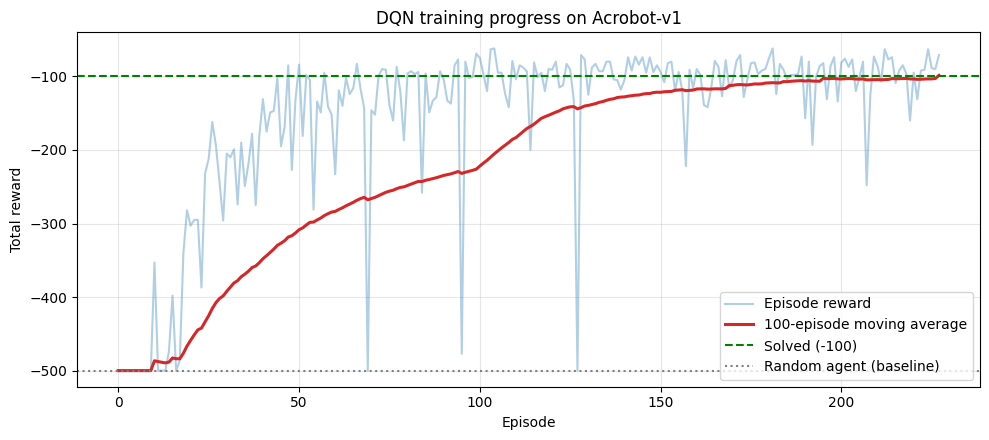

In [16]:
def plot_history(point_history, window=100, solved_score=SOLVED_SCORE):
    points = np.array(point_history)
    moving = [np.mean(points[max(0, k - window + 1):k + 1]) for k in range(len(points))]

    plt.figure(figsize=(10, 4.5))
    plt.plot(points, color="tab:blue", alpha=0.35, label="Episode reward")
    plt.plot(moving, color="tab:red", linewidth=2.2, label=f"{window}-episode moving average")
    plt.axhline(solved_score, color="green", linestyle="--", label=f"Solved ({solved_score:.0f})")
    plt.axhline(np.mean(random_scores), color="gray", linestyle=":", label="Random agent (baseline)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN training progress on Acrobot-v1")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(total_point_history)

<a name="10"></a>
## 10 - Evaluate the Trained Agent

During training the agent still takes random actions some of the time (because of $\epsilon$). To measure what it really learned we run the **greedy policy** ($\epsilon = 0$) on fresh episodes and compare it with the random baseline from section 5.2.

Random agent : mean reward =   -500.0  (std 0.0)
Trained agent: mean reward =    -89.8  (std 12.2)
Trained agent reaches the goal in 90 steps on average (limit is 500).


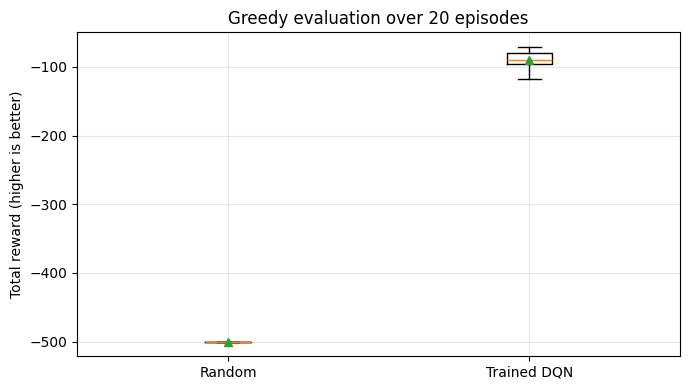

In [17]:
def greedy_policy(state):
    q_values = q_network(np.expand_dims(state, axis=0).astype(np.float32))
    return int(np.argmax(q_values.numpy()[0]))

n_eval = 20
trained_results = [run_episode(env, greedy_policy, seed=1000 + i) for i in range(n_eval)]
trained_scores = [r[0] for r in trained_results]

print(f"Random agent : mean reward = {np.mean(random_scores):8.1f}  (std {np.std(random_scores):.1f})")
print(f"Trained agent: mean reward = {np.mean(trained_scores):8.1f}  (std {np.std(trained_scores):.1f})")
print(f"Trained agent reaches the goal in {-np.mean(trained_scores):.0f} steps on average (limit is 500).")

plt.figure(figsize=(7, 4))
plt.boxplot([random_scores, trained_scores], showmeans=True)
plt.xticks([1, 2], ["Random", "Trained DQN"])
plt.ylabel("Total reward (higher is better)")
plt.title(f"Greedy evaluation over {n_eval} episodes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a name="11"></a>
## 11 - See the Trained Agent in Action

Finally we render one episode of the trained greedy agent and save it as a GIF. The Acrobot starts hanging down, then the agent pumps energy into the system by swinging and finally the tip crosses the target line.

Episode length: 77 steps, saved to acrobot_dqn.gif


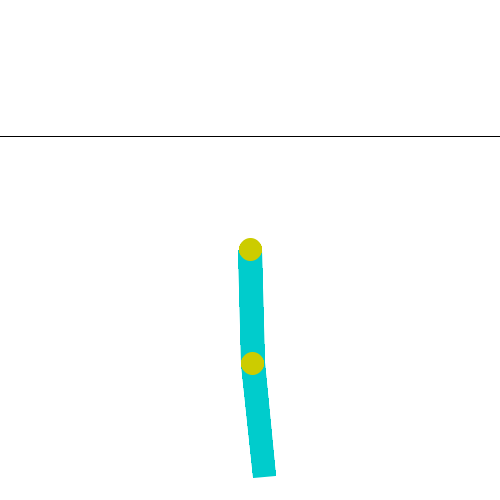

In [18]:
render_env = gym.make("Acrobot-v1", render_mode="rgb_array")

frames = []
state, _ = render_env.reset(seed=7)
frames.append(render_env.render())
done = False
while not done and len(frames) < 300:
    action = greedy_policy(state)
    state, reward, terminated, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
    done = terminated or truncated
render_env.close()

gif_path = "acrobot_dqn.gif"
imageio.mimsave(gif_path, frames, duration=0.04, loop=0)
print(f"Episode length: {len(frames) - 1} steps, saved to {gif_path}")
display(IPyImage(filename=gif_path))

<a name="12"></a>
## 12 - Summary and Experiments to Try

**What I learned**

* A **Q-Network** turns a continuous state into one Q-value per action, so we do not need a table.
* The **target network** gives stable regression targets. The **soft update** $w^-\leftarrow \tau w + (1-\tau)w^-$ makes it trail the main network slowly.
* **Experience replay** breaks the correlation between consecutive samples and lets us reuse data.
* The $y$ target is $R$ for terminal transitions and $R + \gamma\max_{a'}\hat Q(s',a')$ otherwise, and `(1 - done)` implements this for a whole batch at once.
* **$\epsilon$-greedy** balances exploration (early in training) with exploitation (later).
* With Gymnasium, store `terminated` (not `truncated`) as the `done` flag, because a time-limit cut-off is not a real terminal state.

**Experiments to try (change one thing at a time and re-run from section 2)**

1. Set `TAU = 1.0`. This makes the target network a copy of the main network at every step, effectively removing the target network. Does training become less stable?
2. Replace `terminated` with `terminated or truncated` in `memory_buffer.append(...)` and see how it affects learning.
3. Reduce `MEMORY_SIZE` to `1_000` and see how the lack of diverse experience hurts.
4. Try `EPSILON_DECAY = 0.90` (explore less) and `0.995` (explore more).
5. Make the network wider (128 units) or deeper, and compare the number of episodes needed to solve the task.
6. Try other discrete-action environments such as `CartPole-v1` or `MountainCar-v0`. Only `state_size` and `num_actions` change automatically, the rest of the code is reusable.

<a name="13"></a>
## 13 - References

* Mnih, V., Kavukcuoglu, K., Silver, D. et al. *Human-level control through deep reinforcement learning.* Nature 518, 529-533 (2015).
* Mnih, V., Kavukcuoglu, K., Silver, D. et al. *Playing Atari with Deep Reinforcement Learning.* arXiv:1312.5602 (2013).
* Gymnasium documentation, Acrobot environment: https://gymnasium.farama.org/environments/classic_control/acrobot/
* Sutton, R. S. and Barto, A. G. *Reinforcement Learning: An Introduction* (2nd edition).